# 머신러닝 : 모델 평가 (1)

## 모델 평가의 이해

모델을 만들고 이 모델이 **얼마나 잘 작동하는지, 얼마나 정확한지, 신뢰할만한지** 평가해야 한다.  
- 실제 환경에서도 얼마나 잘 예측하고, 얼마나 위험한 판단을 줄이는지 판단하는 과정  
---> 모델을 개선하는 나침반

**모델의 목적 : 일반화(Generalization)**  
새로운 데이터에 대해서도 잘 적용하는 능력   
- 훈련데이터에 잘 맞추기(X)가 아닌, 새로운 데이터를 잘 맞추는 것(O)

**과대접합과 과소접합**  
과소접합 - predictor too inflexible : cannot cappture pattern  
과대접합 - predictor too flexible : fits noise in the data  

**과소접합**
- 모델이 너무 단순해서(복잡X) 데이터의 내재된 구조/패턴을 학습하지 못함.  
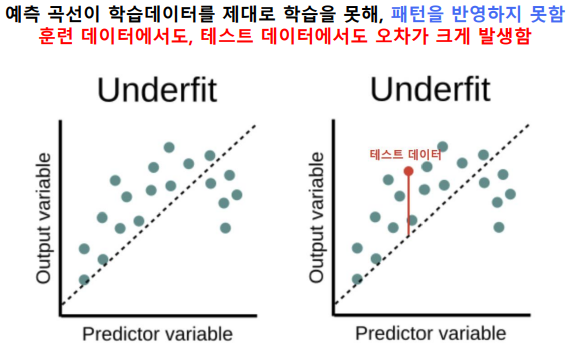

**과대접합**
- 모델이 훈련 데이터에만 너무 잘 맞게 학습(지나치게 복잡하게).. -> 새로운 데이터에 대한 예측이나 분류를 제대로 수행하지 못함.  
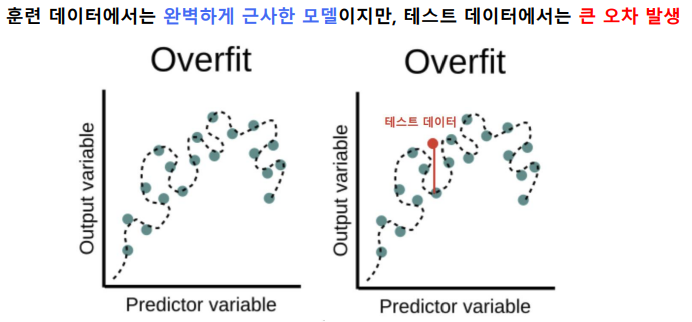

**편향(Bias)와 분산(Variance)** 
 
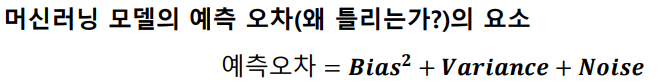
- 편향(Bias): 모델이 단순화되어 발생하는 오류
    - 모델 자체가 잘못된 가정을 하여, 한쪽으로 치우쳐 틀리는 정도
- 분산(Variance): 모델이 데이터의 작은 변화에 민감하게 반응하여 발생하는 오류
    - 조금만 달라져도 모델이 요동쳐 예측이 들쭉날쭉하는 정도
- 불확실성(Noise): 데이터 자체에 있는 본질적인 변동성(어쩔 수 없는 랜덤성; 센서 오차, 사람의 입력 실수 등)

**편향(Bias)**
- 정답을 얼마나 잘못 가정하고 있는지의 정도
    - 모델이 너무 단순해서 복잡한 패턴을 표현 못할 때,
    - 직선으로 표현하는 모델로, 실제로 곡선 패턴인 데이터를 맞추려 할 때

    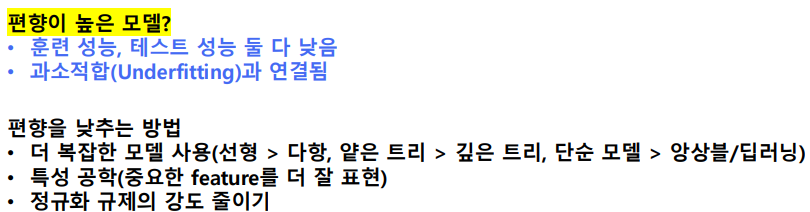

**분산(Variance)**
- 훈련 데이터가 조금만 바뀌어도 예측이 얼마나 요동치는지의 정도
    - 모델이 너무 복잡해서 훈련 데이터의 노이즈까지 외워버린 상황
    - 조금 다른 데이터를 주면, 완전 다른 회귀선/결정경계가 나와버리는 모델  

    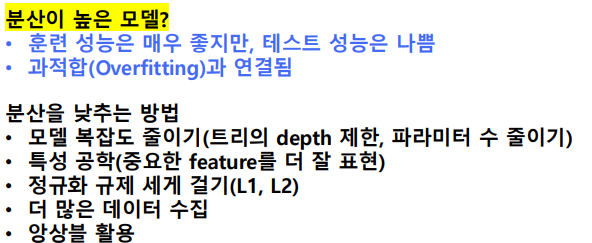

**Bias-Variance Trade-OFF**
- Bias를 줄일려고 모델을 복잡하게 만들면? -> **Variance**가 증가한다.
- Variance를 줄일려고, 모델을 단순하게 만들면? -> **Bias**가 증가한다.

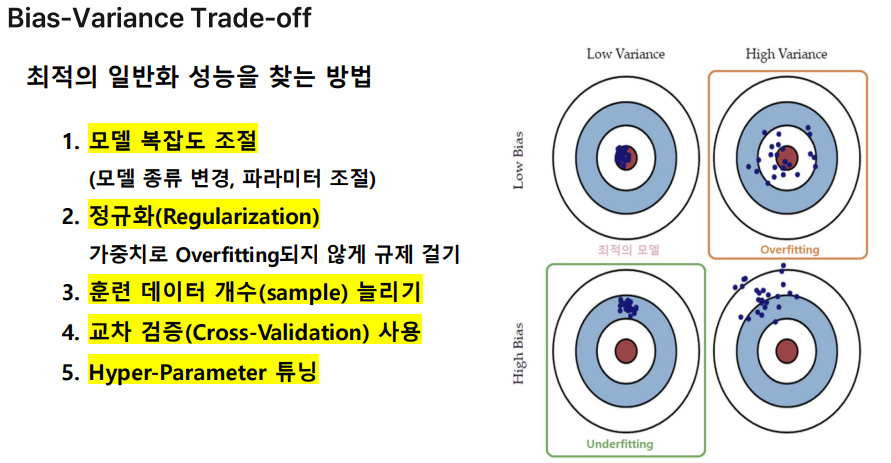

## 평가 지표(Metrics)

- 모델의 상태(일반화 여부, 과접합/ 과소접합 등)를 눈으로 직접 볼 수 없기에, 수치적 기준 등이 필요!!  
    - 훈련 데이터에서 얼마나 잘 맞추고 있는지?
    - 테스트 데이터에서는 얼마나 잘 맞추는지?
    - 과접합인지? 과소접합인지?
    - 편향이 높은지? 분산이 높은지?

### 회귀 모델에서의 평가 지표(Regression Evaluation Metrics)

연속형 값을 예측하는 모델 : 오차를 수치적으로 측정(실제 값 - 예측 값)  
|평가지표|
|---|
|평균 제곱 오차 : MSE|
|평균 제곱근 오차 : RMSE|
|평균 절대 오차 : MAE|
|평균 절대 백분율 오차 : MAPE|
|결정 계수 : R Squared score|

**MSE(Mean Squared Error) - 평균 제곱 오차**  
- 실제 값과 예측 값의 차의 *제곱*의 평균

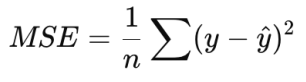

- 큰 오차를 얼마나 줄였는가를 확인 (값이 작을수록 좋다.)
    - 큰 오차에 민감하다.
    - 이상치에 민감하다.
    - 큰 오차를 허용하지 않을 때 적합함.

**RMSE(Root Mean Squared Error)**
- MSE의 제곱근

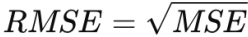

- 원래 단위로 복원(해석에 간편) - 값이 작을수록 좋다.
    - 예측 오차의 평균적인 크기
    - 이상치에 민감.
    - 일반적인 사용

**MAE(Mean Absolute Error)**  
- 실제 값(actual)과 예측 값(prredicted)의 차이의 절댓값의 평균

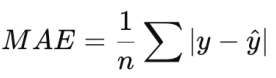

- 오차의 절대값 평균
    - 단위가 원래 단위와 동일하므로 가장 직관적이다.
    - 값이 작을수록 좋다.
    - 이상치에 덜 민감하다.(이상치가 많은 경우에 활용)

**MAPE(Mean Absolute Percentage Error)**
- 오차를 실제 값 대비 비율(%)로 표현

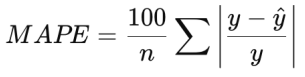

- MAE를 상대적인 오차로 변환
    - MAPE = 0.8% -> 예측이 실제 값에서 평균 8% 오차 발생.
    - 해석이 쉽지만, 실제 값이 0에 가까운 경우, 값이 발산하여 폭증 가능성이 있음.
    - 작은 값 예측에는 부적합하다.

**R^2 Score(결정 계수, Coefficient of Determination)**
- 다른 지표들은 모델마다 값이 다르기 때문에 값만 보고 성능판단하기 어렵.

- 모델의 실제 데이터의 변동성을 얼마나 잘 설명하는지를 나타내는 지표.  

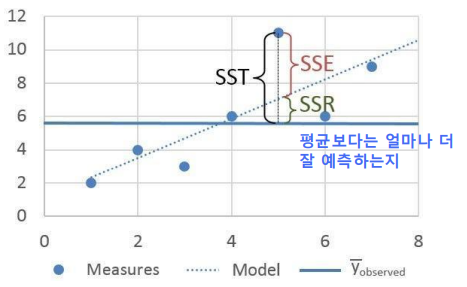

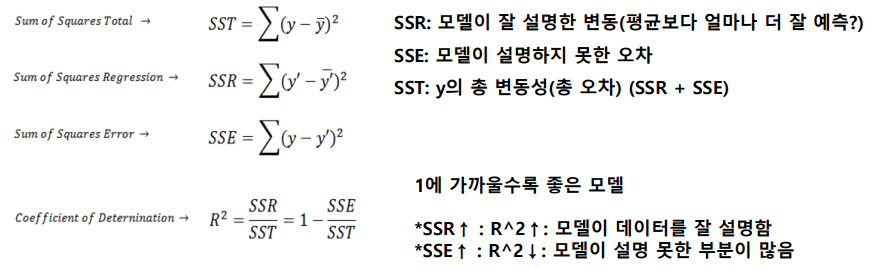

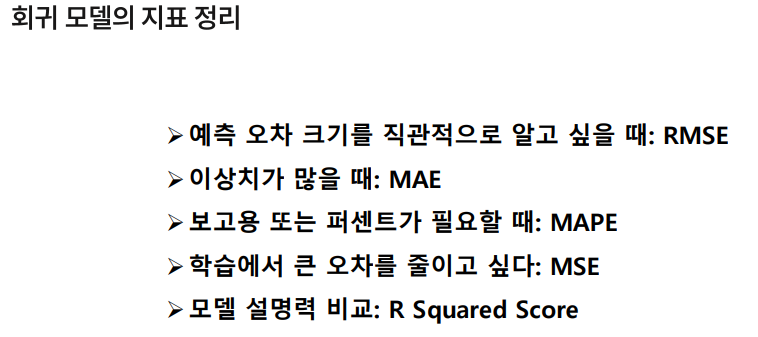

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# 1. 예시용 데이터 생성. (X: 공부시간, y: 시험 점수)
X = np.array([[1],[2],[3],[4],[5],[6],[7],[8],[9],[10]]) # 특성(입력)
y = np.array([15,25,34,46,52,67,73,82,88,95])

# 2. 학습/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

# 3. 모ㅗ델 선택 및 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 4. 예측
y_pred = model.predict(X_test)

# 5. 회귀 평가 지표 계산
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) # 0~1값

# 6. 결과 출력
print(f"MAE (평균 절대 오차)         : {mae:.4f}")
print(f"MSE (평균 제곱 오차)         : {mse:.4f}")
print(f"RMSE (평균 제곱근 오차)      : {rmse:.4f}")
print(f"R2 (결정 계수)              : {r2:.4f}")
print(f"MAPE (평균 절대값 비율 오차)  : {mape:.4f}% (비율)")

MAE (평균 절대 오차)         : 2.2772
MSE (평균 제곱 오차)         : 9.2238
RMSE (평균 제곱근 오차)      : 3.0371
R2 (결정 계수)              : 0.9866
MAPE (평균 절대값 비율 오차)  : 0.0382% (비율)


## 분류 모델에서의 평가 지표

|평가 지표|
|---|
|정확도(Accuracy)|
|오차행렬(Confusion Matrix)|
|정밀도(Precision)|
|재현율(Recall)|
|F1-Score|
|ROC-AUC|

**오차행렬**
- 분류 모델이 예측한 결과와 실제 정답을 비교하여 성능을 평가하는 방법
    - 특히 이진 분류 문제에서 모델이 얼마나 정확하게 예측했는지를 분석하는데 유용  

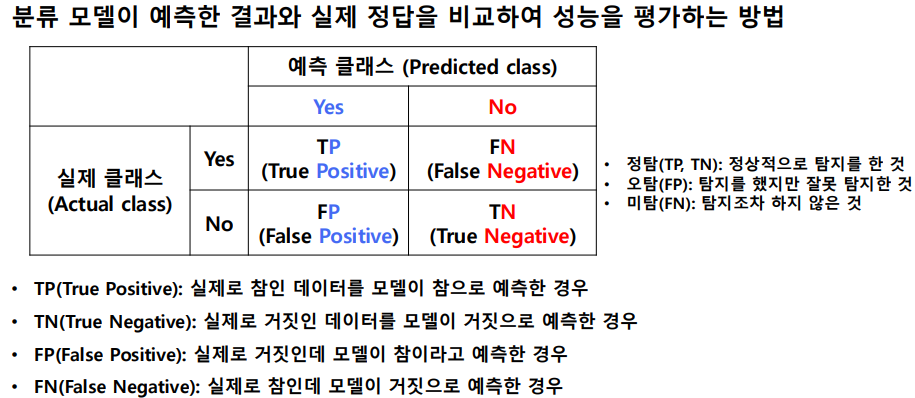

**정확도(Accuracy)**
- 전체 데이터 중에서 모델이 맞춘 비율
- 불균형 데이터에 대해서는 부적절할 수 있다.
- 양성 판정을 신뢰할 수 있는가?  

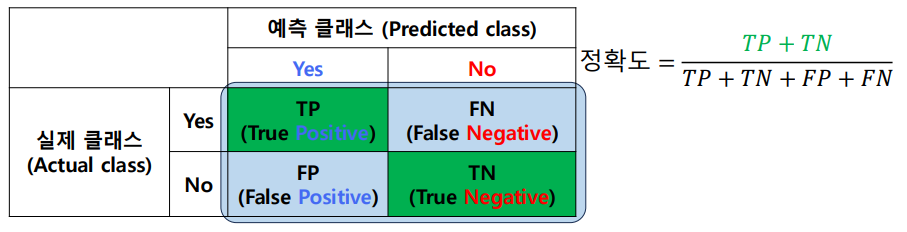

**정밀도(Precision)**
- 모델이 참(Positiv)이라고 예측한 것 중 실제로 참인 비율
- 거짓을 참으로 예측한 경우(FP)를 줄이는 데 초점  
  
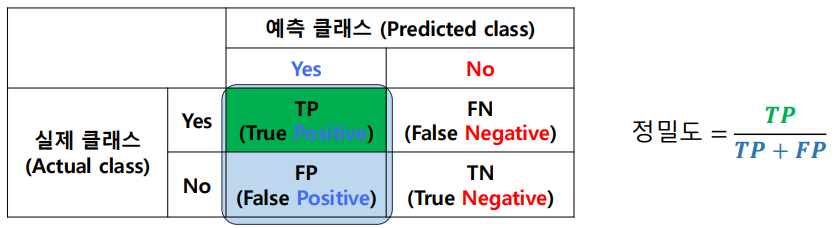

**재현율(Recall) - Sensitivity**
- 실제 참(positive) 중에서 모델이 맞춘 비율
- 실제 양성을 얼마나 놓치지 않고 찾았는가? FN을 줄이는데 초점  

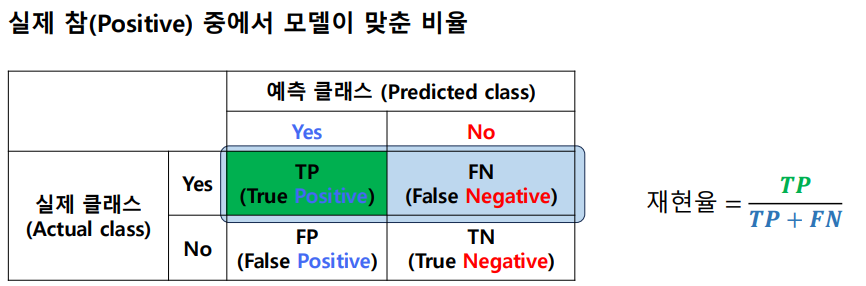

**정밀도(Precision)과 재현율(Recall)의 Trade-Off**
- 임계값에 의해 positive라고 판단할 기준 확률에 따라서 달라진다.
- 정밀도와 재현율은 반비례 관계이다.
    - Threshold를 조절하면서 Recall과 Precision 간의 균형점을 찾는 과정이 매우 중요!  
    
    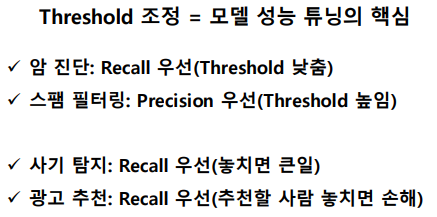

**F1-Score**
- 정밀도(Precision)와 재현율(Recall)의 조화 평균
    - 정밀도와 재현율이 어느 한쪽으로 치우치지 않는 수치를 가질 때 높은 값을 가짐.

    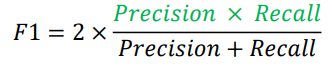

**ROC 곡선(Receiver Operating Characteristic Curve)**
- AUC(Area Under Curve)
    - ROC 곡선 아래 면적을 의미하며, 1에 가까울수록 좋은 성능

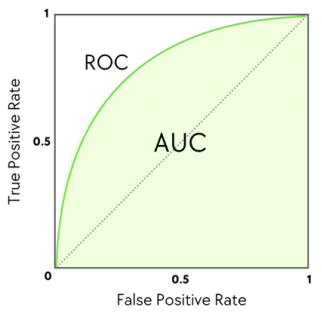

- 불균형 데이터일 때 유용
- 모델 전체적인 분류 능력을 평가할 때



ROC곡선 = **FP 비율 변화에 따른 TP 비율 변화를 나타내는 그래프**  
  
- TPR (Treu Positiv Rate, 재현율 Recall)
    - 실제 양성중에 모델이 맞게 예측한 비율
    - TPR = TP / (TP + FN)
    - 값이 클수록 좋은 모델 (양성을 잘 찾아냄)

- FPR (False Positiv Rate, 1 - 특이도 Specificity)
    - 음성인 케이스에 대해 양성으로 잘못 예측한 비율
        - 1 - 특이도(음성인 케이스에 대해 음성으로 잘 예측)
    - FPR = FP / (FP + TN)
    - 값이 작을수록 좋은 모델(불필요한 오탐을 줄임)

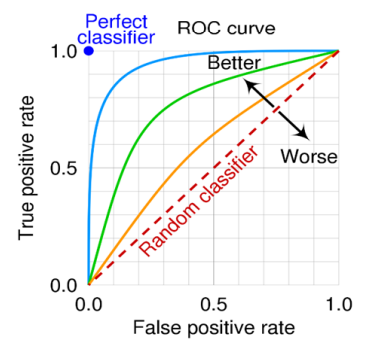

- X축 : FPR (실제 거짓 중 잘못 예측한 비율)
- Y축 : TPR (실제 참 중 맞게 예측한 비율)
    - ROC 곡선이 좌측 상단으로 갈수록 좋은 모델
    - AUC(ROC 곡선 아래 면적)가 1에 가까울수록 성능이 우수

====오차행렬 만들기====
[[89  0]
 [ 3 58]]

====Classification Report====
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        89
           1       1.00      0.95      0.97        61

    accuracy                           0.98       150
   macro avg       0.98      0.98      0.98       150
weighted avg       0.98      0.98      0.98       150


====주요 평가 지표====
Accuracy: 0.9800
Precision: 1.0000
Recall: 0.9508
F1-score: 0.9748
ROC AUC: 0.9754


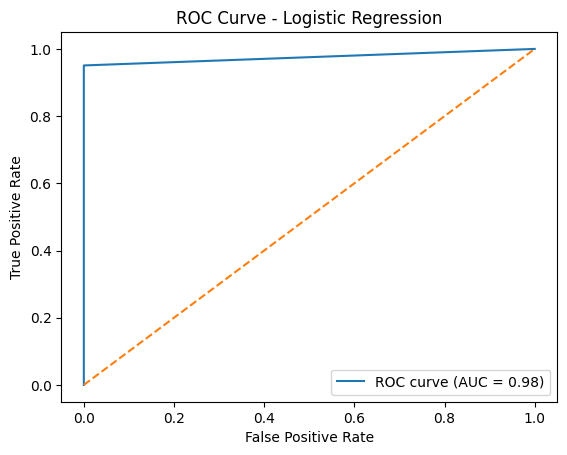

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
)

# 1. 예제용 이진 분류 데이터 생성
X, y = make_classification(
    n_samples=500,          # 샘플 수
    n_features=5,           # 특성 수
    n_informative=3,        # 실제로 유용한 특성 수
    n_redundant=0,          # 중복 특성 수
    n_clusters_per_class=1, # 클래스당 클러스터 수
    weights=[0.6, 0.4],     # 클래스 불균형 비율 (0: 60%, 1: 40%)
    class_sep=1.5,          # 클래스 간 분리 정도 (클수록 잘 분리 됨)
    random_state=42
)

# 2. 훈련/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, stratify=y, random_state=42)

# 3. 분류 모델 선택 및 학습 (로지스틱 회귀)
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. 예측
y_pred = model.predict(X_test) # 클래스(0/1) 예측
y_proba = model.predict_proba(X_test)[:,1] # 양성(1)일 확률 예측

# 5. 평가 지표 계산

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred)

# 오차 행렬 만들기
print('====오차행렬 만들기====')
cm = confusion_matrix(y_test, y_pred)
print(cm)

# classification_report 출력하기
print('\n====Classification Report====')
print(classification_report(y_test, y_pred))

print('\n====주요 평가 지표====')
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# 6. ROC Curve 시각화 (옵션)
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

plt.figure()
# X축: FPR, Y축: TPR
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()